In [1]:
#import libraries 

from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch

c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Load dataset from Hugging Face
dataset = load_dataset("ag_news")

train_data = dataset['train'].shuffle(seed=42).select(range(2000))
test_data = dataset['test'].shuffle(seed=42).select(range(500))

#Labels
label_names = ['World', 'Sports', 'Business', 'Sci/Tech']

print(train_data[0])



{'text': 'Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally.', 'label': 0}


In [3]:
#Tokenization and Preprocessing 

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenization function
def tokenize(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

# Apply tokenization
train_tokenized = train_data.map(tokenize, batched=True)
test_tokenized = test_data.map(tokenize, batched=True)

In [4]:
#Load Bert Model

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=4
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2396.90it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [ ]:
#training aruguments 

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs'
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [8]:
#Evaluation Metrics 

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')

    return {"accuracy": acc, "f1": f1}

In [9]:
#Trainer and Training 
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

trainer.train()



c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s]


TrainOutput(global_step=63, training_loss=1.1104215591672868, metrics={'train_runtime': 1909.1728, 'train_samples_per_second': 1.048, 'train_steps_per_second': 0.033, 'total_flos': 131557890048000.0, 'train_loss': 1.1104215591672868, 'epoch': 1.0})

In [10]:
model.save_pretrained('./news_classifier_model')
tokenizer.save_pretrained('./news_classifier_model')

print("Model saved successfully!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.11it/s]

Model saved successfully!


In [11]:
#Deployment Gradio App
import gradio as gr

# Load saved model
model = BertForSequenceClassification.from_pretrained('./news_classifier_model')
tokenizer = BertTokenizer.from_pretrained('./news_classifier_model')
model.eval()

label_names = ['World', 'Sports', 'Business', 'Sci/Tech']

# Prediction function
def predict(headline):
    inputs = tokenizer(headline, return_tensors='pt',
                       truncation=True, padding=True, max_length=128)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = torch.softmax(outputs.logits, dim=1)[0]
    
    return {label_names[i]: float(probs[i]) for i in range(4)}

# Interface
demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(label="Enter News Headline"),
    outputs=gr.Label(num_top_classes=4),
    title="📰 News Classifier (BERT)",
    description="Classifies news into World, Sports, Business, Sci/Tech"
)

demo.launch()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2812.87it/s]


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Accuracy: 0.8760
F1 Score: 0.8760

 Classification Report:
              precision    recall  f1-score   support

       World       0.94      0.81      0.87       120
      Sports       0.94      0.98      0.96       121
    Business       0.85      0.84      0.84       134
    Sci/Tech       0.79      0.88      0.83       125

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



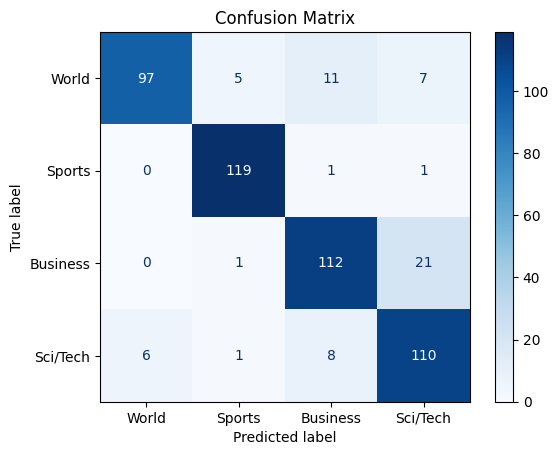

In [12]:
#final evaluation Script
from sklearn.metrics import classification_report

preds, true_labels = [], []

for item in test_data:
    inputs = tokenizer(item['text'], return_tensors='pt',
                       truncation=True, padding=True, max_length=128)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    pred = outputs.logits.argmax().item()
    
    preds.append(pred)
    true_labels.append(item['label'])

# Metrics
acc = accuracy_score(true_labels, preds)
f1 = f1_score(true_labels, preds, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\n Classification Report:")
print(classification_report(true_labels, preds, target_names=label_names))

#Confusion Matrix 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()